In [1]:
quiet_library <- function(...) {suppressPackageStartupMessages(library(...))}
quiet_library(edgeR)
quiet_library(dplyr)
quiet_library(purrr)
quiet_library(furrr)
quiet_library(future)
quiet_library(anndataR)
quiet_library(openxlsx)
quiet_library(BiocParallel)
quiet_library(ggplot2)
quiet_library(tidyverse)
quiet_library(pheatmap)
quiet_library(cowplot)
quiet_library(splines)
quiet_library(Seurat)
quiet_library(parallel)
quiet_library(cluster)
quiet_library(reshape2)
quiet_library(viridisLite)
quiet_library(ggplotify)
quiet_library(dtwclust)
quiet_library(ComplexHeatmap)
quiet_library(circlize)
plan(multisession, workers = 24)
options(future.globals.maxSize = 1024^5*10)
set.seed(0)

# Pseudobulk edgeR Classification_L3

In [2]:
Classification <- 'Classification_L3'
anndata_path <- '/home/liyanguo/MyImmuCell/06_Finnal_raw_count/pseudo_adata_Classification_L3/'
output_root <- paste0('/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L3/', Classification, '/')
dir.create(output_root, recursive = TRUE, showWarnings = FALSE)

In [3]:
frac_clinicl_table <- "/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L3_donor_counts_frac_clinicl_table.xlsx"
levels_group <- c('2_9','10_19','20_29','30_39','40_49','50_59','60_69','70_79','80_89','90_')

## --- load clinical metadata ---

In [4]:
# remove Pregnancy and sample in evening
meta_all <- read.xlsx(frac_clinicl_table, rowNames = TRUE)
meta_all$Ten_year_intervals <- gsub('[-]|[+]','_', meta_all$Ten_year_intervals)

metadata <- meta_all %>%
  dplyr::select(DonorID, ClinicalID, Batch, Gender, Pregnancy, Sampling.time,
                Age_in_Years, Ten_year_intervals) %>%
  dplyr::filter(Pregnancy == 'NO', Sampling.time == 'Morning') %>%
  dplyr::distinct()

## load pseudobulk

In [5]:
read_pseudobulk <- function(h5ad_file) {
  ad <- anndataR::read_h5ad(h5ad_file)
  sum_count <- t(ad$X)
  rownames(sum_count) <- ad$var_names
  colnames(sum_count) <- ad$obs_names
  list(sum_count = sum_count, obs = ad$obs)
}

In [6]:
h5ad_files <- list.files(anndata_path, pattern = ".h5ad$", full.names = TRUE,recursive = T)

## Ten_year_intervals based Design matrix

In [7]:
# function to process one file / cell type
process_pseudobulk_agegroup <- function(h5ad_file) {
  cell_type_name <- basename(h5ad_file) %>% sub("_pseudobulk.h5ad$", "", .)
  message("Processing: ", cell_type_name)
  dir.create(output_root, recursive = TRUE, showWarnings = FALSE)
  
  tryCatch({
    obj <- read_pseudobulk(h5ad_file)
    sum_count <- obj$sum_count
    obs <- obj$obs
    
    # select donor present in clinical metadata
    target_donors <- obs$ClinicalID[obs$ClinicalID %in% metadata$ClinicalID]
    cell_metadata <- metadata %>% filter(ClinicalID %in% target_donors) %>% arrange(Age_in_Years)
    # ensure columns of cell_mat matches the age order
    cell_mat <- sum_count[, cell_metadata$ClinicalID]
    
    # create DGEList
    y <- DGEList(counts = cell_mat, samples = cell_metadata)
    y$samples$Ten_year_intervals <- factor(y$samples$Ten_year_intervals, levels = levels_group)
    y$samples$Gender <- factor(y$samples$Gender, levels = c("Female","Male"))

    # pre-filtered gene list to remove lowly-expressed genes: genes were expressed in at least 10% of donors
    keep.genes <- filterByExpr(y, min.prop = 0.1)
    y <- y[keep.genes, ,keep=FALSE]

    # filtered out genes that had fewer UMIs than the total number of donors
    donor_n <- ncol(y)
    keep.genes <- rowSums(y$counts) >= donor_n
    y <- y[keep.genes, ,keep=FALSE]
    if (all(!keep.genes)) {
      message(paste0(cell_type_name, "No genes passed the expression filter. Skipping this cell type."))
      return(NULL)
    }
      
    y <- normLibSizes(y)
    
    # design matrix for discrete age groups + gender
    design <- model.matrix(~ 0 + Ten_year_intervals + Gender, data = y$samples)
    
    # estimate dispersion and fit
    y <- estimateDisp(y, design, robust = TRUE)
    fit <- glmQLFit(y, design, robust = TRUE)
    
    # contrasts: adjacent group differences
    contr <- makeContrasts(
      `10_19vs2_9`  = Ten_year_intervals10_19 - Ten_year_intervals2_9,
      `20_29vs10_19`= Ten_year_intervals20_29 - Ten_year_intervals10_19,
      `30_39vs20_29`= Ten_year_intervals30_39 - Ten_year_intervals20_29,
      `40_49vs30_39`= Ten_year_intervals40_49 - Ten_year_intervals30_39,
      `50_59vs40_49`= Ten_year_intervals50_59 - Ten_year_intervals40_49,
      `60_69vs50_59`= Ten_year_intervals60_69 - Ten_year_intervals50_59,
      `70_79vs60_69`= Ten_year_intervals70_79 - Ten_year_intervals60_69,
      `80_89vs70_79`= Ten_year_intervals80_89 - Ten_year_intervals70_79,
      `90_vs80_89`  = Ten_year_intervals90_ - Ten_year_intervals80_89,
      levels = design
    )
      
    res_list <- lapply(colnames(contr), function(cn) {
      qlf <- glmQLFTest(fit, contrast = contr[,cn])
      topTags(qlf, n = Inf)$table %>% 
            mutate(
            direction = ifelse(FDR < 0.05 & logFC > 0.5, 'Up',
                       ifelse(FDR < 0.05 & logFC < -0.5, 'Down', "NotSignificant")),
            gene = rownames(.),
            cell_type = cell_type_name,
            pair = cn
           )
    })
    res = do.call(rbind, res_list)
    
    lfc_summarise <- res %>% group_by(cell_type, pair, direction) %>%
          summarise(gene_count = n(), .groups = "drop") %>% pivot_wider(
            names_from = direction,
            values_from = gene_count,
            values_fill = 0
          )
    # same cell type may have no Up or Down gene
    if (!"Up" %in% names(lfc_summarise))   lfc_summarise$Up   <- 0
    if (!"Down" %in% names(lfc_summarise)) lfc_summarise$Down <- 0
    lfc_summarise = lfc_summarise %>% mutate(Background_gene_count = Down + NotSignificant+ Up
                                            ) %>% dplyr::select(cell_type, pair, 
                                                                Down, NotSignificant, Up,
                                                                Background_gene_count)
    
    # save  results table
    write.csv(res, paste0(output_root, cell_type_name, "_edgeR_Ten_year_intervals.csv"),row.names = TRUE)
    write.csv(lfc_summarise, paste0(output_root, cell_type_name, "_edgeR_lfc_summarise.csv"),row.names = FALSE)
    })
}

In [8]:
future_walk(h5ad_files,process_pseudobulk_agegroup,.options = furrr_options(seed = 0L))

Processing: ASDC

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”
Processing: Atypical_B_cells

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”
Processing: Basophils

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”
Processing: CD4pos_Treg

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”
Processing: CD8pos_Tcm

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”
Processing: CD8pos_Tem

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”
Processing: CD8pos_Treg

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”
Processing: cDC1

Warning message in filterByExpr.DGEList(y, 

## Merge

In [9]:
list_file = list.files(output_root,pattern = '_edgeR_lfc_summarise.csv', recursive = T)

In [10]:
merge_result <- lapply(list_file, function(x){
                                    res =  read.csv(paste0(output_root,x))
                                        }
                      )  %>% bind_rows()  %>% replace(is.na(.), 0)
write.csv(merge_result, '/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L3/Classification_L3_edgeR_agegroup_lfc_summarise.csv',row.names = TRUE)

In [11]:
list_file = list.files(output_root,pattern = '_edgeR_Ten_year_intervals.csv', recursive = T)

In [12]:
merge_result <- lapply(list_file, function(x){
                                    res =  read.csv(paste0(output_root,x))
                                    res = res %>% dplyr::filter(direction != 'NotSignificant')
                                        }
                      )  %>% bind_rows()  %>% replace(is.na(.), 0)
write.csv(merge_result, '/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L3/Classification_L3_edgeR_Ten_year_intervals.csv',row.names = TRUE)

# Pseudobulk edgeR Classification_L4

In [4]:
Classification <- 'Classification_L4'
anndata_path <- '/home/liyanguo/MyImmuCell/06_Finnal_raw_count/pseudo_adata_Classification_L4/'
output_root <- paste0('/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/', Classification, '/')
dir.create(output_root, recursive = TRUE, showWarnings = FALSE)

In [5]:
frac_clinicl_table <- "/home/liyanguo/MyImmuCell/06_Finnal_raw_count/Classification_L4_donor_counts_frac_clinicl_table.xlsx"
levels_group <- c('2_9','10_19','20_29','30_39','40_49','50_59','60_69','70_79','80_89','90_')

## --- load clinical metadata ---

In [6]:
meta_all <- read.xlsx(frac_clinicl_table, rowNames = TRUE)
meta_all$Ten_year_intervals <- gsub('[-]|[+]','_', meta_all$Ten_year_intervals)

metadata <- meta_all %>%
  dplyr::select(DonorID, ClinicalID, Batch, Gender, Pregnancy, Sampling.time,
                Age_in_Years, Ten_year_intervals) %>%
  dplyr::filter(Pregnancy == 'NO', Sampling.time == 'Morning') %>%
  dplyr::distinct()

## load pseudobulk

In [7]:
read_pseudobulk <- function(h5ad_file) {
  ad <- anndataR::read_h5ad(h5ad_file)
  sum_count <- t(ad$X)
  rownames(sum_count) <- ad$var_names
  colnames(sum_count) <- ad$obs_names
  list(sum_count = sum_count, obs = ad$obs)
}

In [8]:
h5ad_files <- list.files(anndata_path, pattern = ".h5ad$", full.names = TRUE,recursive = T)

## Ten_year_intervals based Design matrix

In [7]:
# function to process one file / cell type
process_pseudobulk_agegroup <- function(h5ad_file) {
  cell_type_name <- basename(h5ad_file) %>% sub("_pseudobulk.h5ad$", "", .)
  message("Processing: ", cell_type_name)
  dir.create(output_root, recursive = TRUE, showWarnings = FALSE)
  
  tryCatch({
    obj <- read_pseudobulk(h5ad_file)
    sum_count <- obj$sum_count
    obs <- obj$obs
    
    # select donor present in clinical metadata
    target_donors <- obs$ClinicalID[obs$ClinicalID %in% metadata$ClinicalID]
    cell_metadata <- metadata %>% filter(ClinicalID %in% target_donors) %>% arrange(Age_in_Years)
    # ensure columns of cell_mat matches the age order
    cell_mat <- sum_count[, cell_metadata$ClinicalID]
    
    # create DGEList
    y <- DGEList(counts = cell_mat, samples = cell_metadata)
    y$samples$Ten_year_intervals <- factor(y$samples$Ten_year_intervals, levels = levels_group)
    y$samples$Gender <- factor(y$samples$Gender, levels = c("Female","Male"))

    # pre-filtered gene list to remove lowly-expressed genes: genes were expressed in at least 10% of donors
    keep.genes <- filterByExpr(y, min.prop = 0.1)
    y <- y[keep.genes, ,keep=FALSE]

    # filtered out genes that had fewer UMIs than the total number of donors
    donor_n <- ncol(y)
    keep.genes <- rowSums(y$counts) >= donor_n
    y <- y[keep.genes, ,keep=FALSE]
    if (all(!keep.genes)) {
      message(paste0(cell_type_name, "No genes passed the expression filter. Skipping this cell type."))
      return(NULL)
    }
      
    y <- normLibSizes(y)
    
    # design matrix for discrete age groups + gender
    design <- model.matrix(~ 0 + Ten_year_intervals + Gender, data = y$samples)
    
    # estimate dispersion and fit
    y <- estimateDisp(y, design, robust = TRUE)
    fit <- glmQLFit(y, design, robust = TRUE)
    
    # contrasts: adjacent group differences
    contr <- makeContrasts(
      `10_19vs2_9`  = Ten_year_intervals10_19 - Ten_year_intervals2_9,
      `20_29vs10_19`= Ten_year_intervals20_29 - Ten_year_intervals10_19,
      `30_39vs20_29`= Ten_year_intervals30_39 - Ten_year_intervals20_29,
      `40_49vs30_39`= Ten_year_intervals40_49 - Ten_year_intervals30_39,
      `50_59vs40_49`= Ten_year_intervals50_59 - Ten_year_intervals40_49,
      `60_69vs50_59`= Ten_year_intervals60_69 - Ten_year_intervals50_59,
      `70_79vs60_69`= Ten_year_intervals70_79 - Ten_year_intervals60_69,
      `80_89vs70_79`= Ten_year_intervals80_89 - Ten_year_intervals70_79,
      `90_vs80_89`  = Ten_year_intervals90_ - Ten_year_intervals80_89,
      levels = design
    )
      
    res_list <- lapply(colnames(contr), function(cn) {
      qlf <- glmQLFTest(fit, contrast = contr[,cn])
      topTags(qlf, n = Inf)$table %>% 
            mutate(
            direction = ifelse(FDR < 0.05 & logFC > 0.5, 'Up',
                       ifelse(FDR < 0.05 & logFC < -0.5, 'Down', "NotSignificant")),
            gene = rownames(.),
            cell_type = cell_type_name,
            pair = cn
           )
    })
    res = do.call(rbind, res_list)
    
    lfc_summarise <- res %>% group_by(cell_type, pair, direction) %>%
          summarise(gene_count = n(), .groups = "drop") %>% pivot_wider(
            names_from = direction,
            values_from = gene_count,
            values_fill = 0
          )
    # same cell type may have no Up or Down gene
    if (!"Up" %in% names(lfc_summarise))   lfc_summarise$Up   <- 0
    if (!"Down" %in% names(lfc_summarise)) lfc_summarise$Down <- 0
    lfc_summarise = lfc_summarise %>% mutate(Background_gene_count = Down + NotSignificant+ Up
                                            ) %>% dplyr::select(cell_type, pair, 
                                                                Down, NotSignificant, Up,
                                                                Background_gene_count)
    
    # save  results table
    write.csv(res, paste0(output_root, cell_type_name, "_edgeR_Ten_year_intervals.csv"),row.names = TRUE)
    write.csv(lfc_summarise, paste0(output_root, cell_type_name, "_edgeR_lfc_summarise.csv"),row.names = FALSE)
    })
}

In [19]:
future_walk(h5ad_files,process_pseudobulk_agegroup,.options = furrr_options(seed = 0L))

Processing: Adaptive_NK_cells

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”
Processing: ALPL__MARCKS__NDNs

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”
Processing: ASDC

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”
Processing: Atypical_naïve_B_cells

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”
Processing: Basophils

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”
Processing: CCR4__CD8pos_Tcm

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”
Processing: CCR4pos_CD8pos_Tcm

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”
Processing: CD14pos_cDC2

Wa

## Splines Design matrix

In [8]:
# function to process one file / cell type
process_pseudobulk_age_spline <- function(h5ad_file) {
  set.seed(0)
  cell_type_name <- basename(h5ad_file) %>% sub("_pseudobulk.h5ad$", "", .)
  message("Processing: ", cell_type_name)
  dir.create(output_root, recursive = TRUE, showWarnings = FALSE)
  
  tryCatch({
    obj <- read_pseudobulk(h5ad_file)
    sum_count <- obj$sum_count
    obs <- obj$obs
    
    # select donor present in clinical metadata
    target_donors <- obs$ClinicalID[obs$ClinicalID %in% metadata$ClinicalID]
    cell_metadata <- metadata %>% filter(ClinicalID %in% target_donors) %>% arrange(Age_in_Years)
    # ensure columns of cell_mat matches the age order
    cell_mat <- sum_count[, cell_metadata$ClinicalID]
    message("Processing: ", ncol(cell_mat))
    
    # create DGEList
    y <- DGEList(counts = cell_mat, samples = cell_metadata)
    
    # pre-filtered gene list to remove lowly-expressed genes: genes were expressed in at least 10% of donors
    # filtered out genes that had fewer UMIs than the total number of donors
    keep.genes <- filterByExpr(y, min.prop = 0.1) & rowSums(y$counts) >= ncol(y)
    y <- y[keep.genes, ,keep=FALSE]
    if (all(!keep.genes)) {
      message(paste0(cell_type_name, "No genes passed the expression filter. Skipping this cell type."))
    }
    
    y <- normLibSizes(y)
    
    # Splines desgin
    age <- ns(y$samples$Age_in_Years, df=3)
    gender <- factor(y$samples$Gender,levels = c('Female','Male'))
    design <- model.matrix(~ 0 + age + gender)
    colnames(design) <- gsub("gender", "", colnames(design))
    
    # estimate dispersion and fit
    y <- estimateDisp(y, design, robust = TRUE)
    fit <- glmQLFit(y, design, robust = TRUE)
    
    # differences
    qlf = glmQLFTest(fit, coef=1:3)
    res <- topTags(qlf, n = Inf)$table %>% mutate(
      gene = rownames(.),
      cell_type = cell_type_name
    )
    
    # Calculate gene_amplitude (max-min smooth.spline value)
    logCPM.fit <- cpm(fit, log=TRUE)
    process_gene_amplitude <- function(geneID) {
      df <- data.frame(age = y$samples$Age_in_Years,
                       logCPM_fit.i = logCPM.fit[geneID, ]
      )
      sm <- smooth.spline(df$age, df$logCPM_fit.i, df = 5)
      # 计算幅度
      amp <- round(max(sm$y) - min(sm$y), 2)
      return(data.frame(gene = geneID,amplitude = amp))
    }
    amp_list <- mclapply(rownames(res), process_gene_amplitude, mc.cores = 1)
    amp_df = do.call(rbind,amp_list) %>% as.data.frame() %>% arrange(1/amplitude)
    res = left_join(res,amp_df,by = 'gene')

    #性别相关差异基因
    contr <- makeContrasts(
      `FemalevsMale`  = Female - Male,
      levels = design
    )
    qlf_gender <- glmQLFTest(fit, contrast = contr[,1])
    res_gender <- topTags(qlf_gender, n = Inf)$table %>% mutate(
      gene = rownames(.)
    ) %>% filter(FDR<0.05,abs(logFC)>1)
    
    res = res %>% mutate(
      Significant = ifelse(FDR < 0.05 & amplitude > 1 & (!gene %in% res_gender$gene), 'Significant', "NotSignificant")
    )
    
    lfc_summarise <- res %>% group_by(cell_type, Significant) %>%
      summarise(gene_count = n(), .groups = "drop") %>% pivot_wider(
        names_from = Significant,
        values_from = gene_count,
        values_fill = 0
      )
    
    if (!"Significant" %in% names(lfc_summarise))   lfc_summarise$Significant   <- 0
    lfc_summarise = lfc_summarise %>% mutate(Background_gene_count = Significant + NotSignificant
    ) %>% dplyr::select(cell_type, Significant, NotSignificant, Background_gene_count)
    
    write.csv(res, paste0(output_root, cell_type_name, "_edgeR_age_spline_deg.csv"),row.names = TRUE)
    write.csv(lfc_summarise, paste0(output_root, cell_type_name, "_edgeR_age_spline_deg_summarise.csv"),row.names = FALSE)

    # plot and cluster
    res_sub <- subset(res,res$Significant=='Significant')
    sig_genes = res_sub$gene
    if (length(sig_genes) >= 10) {
      fitted_expr <- logCPM.fit[sig_genes,]
      fitted_z <- t(scale(t(fitted_expr)))
      
      sil <- sapply(2:6, function(k){
        km <- kmeans(fitted_z, centers = k)
        ss <- silhouette(km$cluster, dist(fitted_z))
        mean(ss[, 3])
      })
      optimal_k <- which.max(sil) + 1
      pam <- pam(fitted_z, k = optimal_k, metric = "euclidean")
      
      annotation_row <- data.frame(Cluster = factor(pam$cluster),row.names = rownames(fitted_z))
      annotation_col <- data.frame(age_group = factor(y$samples$Ten_year_intervals,levels = levels_group),
                                   row.names =  colnames(fitted_z))
      col_fun <- colorRamp2(
      seq(min(fitted_z), max(fitted_z), length.out = 7),
      c("#5A5085", "#4A66AF", "#7DC29F", "#F2F1B1",
        "#F3B86E", "#CC5B59", "#8F1E40")
        )
      ht <- Heatmap(
          fitted_z,
          name = "Z",
          col = col_fun,
          cluster_rows = TRUE,
          cluster_columns = FALSE,
          show_row_names = TRUE,
          show_column_names = FALSE,
          row_names_gp = gpar(fontsize = 5),
          top_annotation = HeatmapAnnotation(df = annotation_col,col = list(age_group = c('2_9' = "#6495ED",'10_19' = "#D1352B",'20_29' = "#D2EBC8",'30_39' = "#D877B4",
                                                                            '40_49' = "#EE934E",'50_59' = "#5DA086",'60_69' = "#e8df9a",'70_79' = "#f0c1f5",
                                                                            '80_89' = "#AED0DF",'90_' = '#A7C4E4'))),
          left_annotation = rowAnnotation(df = annotation_row,col = list(Cluster=c('1'="#2E86AB",'2'="#A4B494",'3'="#F18F01",'4'="#C73E1D",'5'='#C8B6A6'))),
          use_raster = TRUE,
          raster_quality = 10,
          column_title = paste0(
            "Age-associated transcriptional trajectories: ",
            length(sig_genes), " genes"
          )
        )
      pdf(
          paste0(output_root, cell_type_name, "_edgeR_age_spline_cluster.pdf"),
          width = 10, height = 10
        )
      draw(ht)
      dev.off()
      mean_list = apply(fitted_z, 1, function(gene_expr) {
        tapply(gene_expr, INDEX = annotation_col$age_group, FUN = mean)
      }) %>% 
        t() %>% 
        as.data.frame() %>%
        rename_with(~ paste0("mean_exp_", .x))  %>% 
        merge(annotation_row,by="row.names") %>%
        rename(gene=Row.names) %>% 
        write.csv(paste0(output_root, cell_type_name, "_edgeR_age_spline_significant_deg_mean_cluster.csv"),row.names = TRUE)
      
    } else {
      message(paste0(cell_type_name, "Few sig_genes."))
    }
    #Seurat check data
    # object <- CreateSeuratObject(counts = sum_count) %>% NormalizeData(verbose = F) %>% FindVariableFeatures(verbose = F) %>% ScaleData(features = rownames(.)) %>% RunPCA(features = rownames(.),verbose = F) %>% 
    #   RunUMAP(dims = 1:10,verbose = F) %>% FindNeighbors(dims = 1:10,verbose = F) %>% FindClusters(verbose = F)
    # p1 = VlnPlot(object, features = c("nFeature_RNA", "nCount_RNA"))
    # p2 = DimPlot(object)
    # ggsave2(paste0(output_root,cell_type_name,'_dimplot.png'),p1|p2,width = 8,height = 5)
    # ggsave2(paste0(output_root,cell_type_name,'_dimplot.pdf'),p1|p2,width = 8,height = 5)
    message("Processing: Done")
  })
}

In [9]:
future_walk(h5ad_files[!grepl('NDNs',h5ad_files)], process_pseudobulk_age_spline)

Processing: Adaptive_NK_cells

Processing: 926

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”
Processing: Done

Processing: ASDC

Processing: 889

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”
ASDCFew sig_genes.

Processing: Done

Processing: Atypical_naïve_B_cells

Processing: 901

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”
Processing: Done

Processing: Basophils

Processing: 907

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”
Processing: Done

Warning message:
“UNRELIABLE VALUE: Future (<unnamed-1>) unexpectedly generated random numbers without specifying argument 'seed'. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'seed=TRUE'. This ensures th

In [10]:
future_walk(h5ad_files[grepl('NDNs',h5ad_files)],process_pseudobulk_age_spline)

Processing: ALPL__MARCKS__NDNs

Processing: 922

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”
Processing: Done

Warning message:
“UNRELIABLE VALUE: Future (<unnamed-25>) unexpectedly generated random numbers without specifying argument 'seed'. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced. To disable this check, use 'seed=NULL', or set option 'future.rng.onMisuse' to "ignore".”
Processing: Core_NDNs

Processing: 926

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”
Processing: Done

Warning message:
“UNRELIABLE VALUE: Future (<unnamed-26>) unexpectedly generated random numbers without specifying argument 'seed'. There is a risk that those random numbers are not statistically sound and the overall 

# Pathway

In [18]:
list_files = list.files(output_root,pattern = '_edgeR_age_spline_significant_deg_mean_cluster.csv$', recursive = T,full.names = T)

## pathway kegg_hallmarkg

In [78]:
GetEnrich <- function(features_path) {
  cols = c("#F47E5D", "#CA3D74", "#7F2880", "#463873")
  plot_term_number = 15
  gmtfile = '/home/liyanguo/Marker/msigdb_v2025.1.Hs/kegg_hallmarkg.gmt'
  cell_type_name <- basename(features_path) %>% sub("_edgeR_age_spline_significant_deg_mean_cluster.csv$", "", .)
  message("Processing: ", cell_type_name)
  
  suppressPackageStartupMessages({
    library(clusterProfiler)
    library(ggplot2)
    library(dplyr)
  })
  
  Term <- read.gmt(gmtfile)
  ego_comb <- NULL
  
  features = read.csv(features_path)
  # 循环富集分析
  for (cluster in unique(features$Cluster)) {
    gene_list <- features %>% filter(Cluster == cluster)
    ego <- enricher(gene_list$gene, TERM2GENE = Term)
    if (!is.null(ego)){
        result <- ego@result %>%
        mutate(
        GeneRatio.num = Count / length(gene_list),
        group = cluster
        ) %>%
        filter(p.adjust< 0.05) %>%
        arrange(desc(GeneRatio.num))
    
        ego_comb <- rbind(ego_comb, result)
    }
  }
  
  # 筛选top结果并准备绘图
  ego_comb_sub <- ego_comb %>%
    group_by(group) %>%
    top_n(-plot_term_number, pvalue) %>%
    mutate(
      logp = -log10(pvalue),
      Description = factor(Description, levels = rev(unique(Description))),
      group = factor(group, levels = rev(unique(group)))
    )
  
  # 保存结果
  output_file <- paste0(output_root, cell_type_name,"_GetEnrich_kegg_hallmark")
  write.csv(ego_comb_sub, paste0(output_file, ".csv"))
    
  # 绘图
  p <- ggplot(ego_comb_sub, aes(x = group, y = Description)) + 
    geom_point(aes(size = GeneRatio.num, color = logp)) + 
    scale_color_gradientn(colours = colorRampPalette(cols)(100)) +
    theme_bw(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(y = NULL, title = "")+
    ggtitle(cell_type_name)
  
  ggsave(paste0(output_root,cell_type_name, "age_spline_GetEnrich_kegg_hallmark.png"), p, width = 10, height = 10)
  ggsave(paste0(output_root,cell_type_name, "age_spline_GetEnrich_kegg_hallmark.pdf"), p, width = 10, height = 10)
}

In [79]:
mclapply(list_files, GetEnrich, mc.cores = 2)

[[1]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Adaptive_NK_cellsage_spline_GetEnrich_kegg_hallmark.pdf"

[[2]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/ALPL__MARCKS__NDNsage_spline_GetEnrich_kegg_hallmark.pdf"

[[3]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Atypical_naïve_B_cellsage_spline_GetEnrich_kegg_hallmark.pdf"

[[4]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Basophilsage_spline_GetEnrich_kegg_hallmark.pdf"

[[5]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CCR4__CD8pos_Tcmage_spline_GetEnrich_kegg_hallmark.pdf"

[[6]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CCR4pos_CD8pos_Tcmage_spline_GetEnrich_kegg_hallmark.pdf"

[[7]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD14pos_cDC2age_spline_GetEnrich_kegg_hallmark.pdf"

[[8]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD1Cpos_cDC2age_spline_GetEnrich_kegg_hallmark.pdf"

[[9]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27__IgD__atypical_memory_B_cellsage_spline_GetEnrich_kegg_hallmark.pdf"

[[10]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27__MAITage_spline_GetEnrich_kegg_hallmark.pdf"

[[11]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27__Th1age_spline_GetEnrich_kegg_hallmark.pdf"

[[12]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27__Th17age_spline_GetEnrich_kegg_hallmark.pdf"

[[13]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27pos_IgDpos_atypical_memory_B_cellsage_spline_GetEnrich_kegg_hallmark.pdf"

[[14]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27pos_MAITage_spline_GetEnrich_kegg_hallmark.pdf"

[[15]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27pos_Th1age_spline_GetEnrich_kegg_hallmark.pdf"

[[16]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27pos_Th17age_spline_GetEnrich_kegg_hallmark.pdf"

[[17]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD56bright_NK_cellsage_spline_GetEnrich_kegg_hallmark.pdf"

[[18]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD56dim_NK_cellsage_spline_GetEnrich_kegg_hallmark.pdf"

[[19]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD62Lhi_GZMKpos_Vδ2pos_T_cellsage_spline_GetEnrich_kegg_hallmark.pdf"

[[20]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD8pos_Temraage_spline_GetEnrich_kegg_hallmark.pdf"

[[21]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD8pos_Tregage_spline_GetEnrich_kegg_hallmark.pdf"

[[22]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/cDC1age_spline_GetEnrich_kegg_hallmark.pdf"

[[23]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Core_classical_monocytesage_spline_GetEnrich_kegg_hallmark.pdf"

[[24]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Core_NDNsage_spline_GetEnrich_kegg_hallmark.pdf"

[[25]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CXCL8__PTGS2pos_NDNsage_spline_GetEnrich_kegg_hallmark.pdf"

[[26]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_

In [215]:
list_file = list.files(output_root,pattern = '_GetEnrich_kegg_hallmark.csv$', recursive = T)

In [216]:
merge_result <- lapply(list_file, function(x){
    res =  read.csv(paste0(output_root,x),row.names = 1) %>% 
    mutate(celltype = gsub('_GetEnrich_kegg_hallmark.csv','',x))
                                        }
                      ) %>% bind_rows()
#lapply(merge_result,dim)
write.csv(merge_result, '/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4_kegg.csv',row.names = TRUE)

## pathway GO

In [80]:
GetEnrich <- function(features_path) {
  cols = c("#F47E5D", "#CA3D74", "#7F2880", "#463873")
  plot_term_number = 15
  gmtfile = '/home/liyanguo/Marker/msigdb_v2025.1.Hs/msigdb_v2025.1.Hs_GMTs/c5.go.bp.v2025.1.Hs.symbols.gmt'
    
  cell_type_name <- basename(features_path) %>% sub("_edgeR_age_spline_significant_deg_mean_cluster.csv$", "", .)
  message("Processing GO: ", cell_type_name)
  
  suppressPackageStartupMessages({
    library(clusterProfiler)
    library(ggplot2)
    library(dplyr)
  })
  
  Term <- read.gmt(gmtfile)
  ego_comb <- NULL
  
  features = read.csv(features_path)
  # 循环富集分析
  for (cluster in unique(features$Cluster)) {
    gene_list <- features %>% filter(Cluster == cluster)
    ego <- enricher(gene_list$gene, TERM2GENE = Term)
    if (!is.null(ego)){
        result <- ego@result %>%
        mutate(
        GeneRatio.num = Count / length(gene_list),
        group = cluster
        ) %>%
        filter(p.adjust< 0.05) %>%
        arrange(desc(GeneRatio.num))
    
        ego_comb <- rbind(ego_comb, result)
    }
  }
  
  # 筛选top结果并准备绘图
  ego_comb_sub <- ego_comb %>%
    group_by(group) %>%
    top_n(-plot_term_number, pvalue) %>%
    mutate(
      logp = -log10(pvalue),
      Description = factor(Description, levels = rev(unique(Description))),
      group = factor(group, levels = rev(unique(group)))
    )
  
  # 保存结果
  output_file <- paste0(output_root, cell_type_name,"_GetEnrich_GO")
  write.csv(ego_comb_sub, paste0(output_file, ".csv"))
    
  # 绘图
  p <- ggplot(ego_comb_sub, aes(x = group, y = Description)) + 
    geom_point(aes(size = GeneRatio.num, color = logp)) + 
    scale_color_gradientn(colours = colorRampPalette(cols)(100)) +
    theme_bw(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(y = NULL, title = "")+
    ggtitle(cell_type_name)
  
  ggsave(paste0(output_root,cell_type_name, "age_spline_GetEnrich_GO.png"), p, width = 10, height = 10)
  ggsave(paste0(output_root,cell_type_name, "age_spline_GetEnrich_GO.pdf"), p, width = 10, height = 10)
}

In [81]:
mclapply(list_files, GetEnrich, mc.cores = 2)

[[1]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Adaptive_NK_cellsage_spline_GetEnrich_GO.pdf"

[[2]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/ALPL__MARCKS__NDNsage_spline_GetEnrich_GO.pdf"

[[3]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Atypical_naïve_B_cellsage_spline_GetEnrich_GO.pdf"

[[4]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Basophilsage_spline_GetEnrich_GO.pdf"

[[5]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CCR4__CD8pos_Tcmage_spline_GetEnrich_GO.pdf"

[[6]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CCR4pos_CD8pos_Tcmage_spline_GetEnrich_GO.pdf"

[[7]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD14pos_cDC2age_spline_GetEnrich_GO.pdf"

[[8]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD1Cpos_cDC2age_spline_GetEnrich_GO.pdf"

[[9]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27__IgD__atypical_memory_B_cellsage_spline_GetEnrich_GO.pdf"

[[10]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27__MAITage_spline_GetEnrich_GO.pdf"

[[11]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27__Th1age_spline_GetEnrich_GO.pdf"

[[12]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27__Th17age_spline_GetEnrich_GO.pdf"

[[13]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27pos_IgDpos_atypical_memory_B_cellsage_spline_GetEnrich_GO.pdf"

[[14]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27pos_MAITage_spline_GetEnrich_GO.pdf"

[[15]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27pos_Th1age_spline_GetEnrich_GO.pdf"

[[16]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27pos_Th17age_spline_GetEnrich_GO.pdf"

[[17]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD56bright_NK_cellsage_spline_GetEnrich_GO.pdf"

[[18]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD56dim_NK_cellsage_spline_GetEnrich_GO.pdf"

[[19]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD62Lhi_GZMKpos_Vδ2pos_T_cellsage_spline_GetEnrich_GO.pdf"

[[20]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD8pos_Temraage_spline_GetEnrich_GO.pdf"

[[21]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD8pos_Tregage_spline_GetEnrich_GO.pdf"

[[22]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/cDC1age_spline_GetEnrich_GO.pdf"

[[23]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Core_classical_monocytesage_spline_GetEnrich_GO.pdf"

[[24]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Core_NDNsage_spline_GetEnrich_GO.pdf"

[[25]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CXCL8__PTGS2pos_NDNsage_spline_GetEnrich_GO.pdf"

[[26]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/DN_T_cellsage_spline_GetEnrich_GO.pdf"

[[27]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Early_memory_B_cellsage_spline_GetEnrich_GO.pdf"

[[28]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_

In [196]:
list_file = list.files(output_root,pattern = '_GetEnrich_GO.csv$', recursive = T)
list_file= list_file[-22]

In [201]:
merge_result <- lapply(list_file, function(x){
    res =  read.csv(paste0(output_root,x),row.names = 1) %>% 
    mutate(celltype = gsub('_GetEnrich_GO.csv','',x))
                                        }
                      ) %>% bind_rows()
#lapply(merge_result,dim)
write.csv(merge_result, '/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4_GO.csv',row.names = TRUE)

## pathway reactome

In [82]:
GetEnrich <- function(features_path) {
  cols = c("#F47E5D", "#CA3D74", "#7F2880", "#463873")
  plot_term_number = 15
  gmtfile = '/home/liyanguo/Marker/msigdb_v2025.1.Hs/msigdb_v2025.1.Hs_GMTs/c2.cp.reactome.v2025.1.Hs.symbols.gmt'
  
  cell_type_name <- basename(features_path) %>% sub("_edgeR_age_spline_significant_deg_mean_cluster.csv$", "", .)
  message("Processing: ", cell_type_name)
  
  suppressPackageStartupMessages({
    library(clusterProfiler)
    library(ggplot2)
    library(dplyr)
  })
  
  Term <- read.gmt(gmtfile)
  ego_comb <- NULL
  
  features = read.csv(features_path)
  # 循环富集分析
  for (cluster in unique(features$Cluster)) {
    gene_list <- features %>% filter(Cluster == cluster)
    ego <- enricher(gene_list$gene, TERM2GENE = Term)
    if (!is.null(ego)){
        result <- ego@result %>%
        mutate(
        GeneRatio.num = Count / length(gene_list),
        group = cluster
        ) %>%
        filter(p.adjust< 0.05) %>%
        arrange(desc(GeneRatio.num))
    
        ego_comb <- rbind(ego_comb, result)
    }
  }
  
  # 筛选top结果并准备绘图
  ego_comb_sub <- ego_comb %>%
    group_by(group) %>%
    top_n(-plot_term_number, pvalue) %>%
    mutate(
      logp = -log10(pvalue),
      Description = factor(Description, levels = rev(unique(Description))),
      group = factor(group, levels = rev(unique(group)))
    )
  
  # 保存结果
  output_file <- paste0(output_root, cell_type_name,"_GetEnrich_reactome")
  write.csv(ego_comb_sub, paste0(output_file, ".csv"))
    
  # 绘图
  p <- ggplot(ego_comb_sub, aes(x = group, y = Description)) + 
    geom_point(aes(size = GeneRatio.num, color = logp)) + 
    scale_color_gradientn(colours = colorRampPalette(cols)(100)) +
    theme_bw(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(y = NULL, title = "")+
    ggtitle(cell_type_name)
  
  ggsave(paste0(output_root,cell_type_name, "age_spline_GetEnrich_reactome.png"), p, width = 10, height = 10)
  ggsave(paste0(output_root,cell_type_name, "age_spline_GetEnrich_reactome.pdf"), p, width = 10, height = 10)
}

In [83]:
mclapply(list_files, GetEnrich, mc.cores = 2)

[[1]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Adaptive_NK_cellsage_spline_GetEnrich_reactome.pdf"

[[2]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/ALPL__MARCKS__NDNsage_spline_GetEnrich_reactome.pdf"

[[3]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Atypical_naïve_B_cellsage_spline_GetEnrich_reactome.pdf"

[[4]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Basophilsage_spline_GetEnrich_reactome.pdf"

[[5]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CCR4__CD8pos_Tcmage_spline_GetEnrich_reactome.pdf"

[[6]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CCR4pos_CD8pos_Tcmage_spline_GetEnrich_reactome.pdf"

[[7]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD14pos_cDC2age_spline_GetEnrich_reactome.pdf"

[[8]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD1Cpos_cDC2age_spline_GetEnrich_reactome.pdf"

[[9]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27__IgD__atypical_memory_B_cellsage_spline_GetEnrich_reactome.pdf"

[[10]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27__MAITage_spline_GetEnrich_reactome.pdf"

[[11]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27__Th1age_spline_GetEnrich_reactome.pdf"

[[12]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27__Th17age_spline_GetEnrich_reactome.pdf"

[[13]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27pos_IgDpos_atypical_memory_B_cellsage_spline_GetEnrich_reactome.pdf"

[[14]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27pos_MAITage_spline_GetEnrich_reactome.pdf"

[[15]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27pos_Th1age_spline_GetEnrich_reactome.pdf"

[[16]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27pos_Th17age_spline_GetEnrich_reactome.pdf"

[[17]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD56bright_NK_cellsage_spline_GetEnrich_reactome.pdf"

[[18]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD56dim_NK_cellsage_spline_GetEnrich_reactome.pdf"

[[19]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD62Lhi_GZMKpos_Vδ2pos_T_cellsage_spline_GetEnrich_reactome.pdf"

[[20]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD8pos_Temraage_spline_GetEnrich_reactome.pdf"

[[21]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD8pos_Tregage_spline_GetEnrich_reactome.pdf"

[[22]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/cDC1age_spline_GetEnrich_reactome.pdf"

[[23]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Core_classical_monocytesage_spline_GetEnrich_reactome.pdf"

[[24]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Core_NDNsage_spline_GetEnrich_reactome.pdf"

[[25]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CXCL8__PTGS2pos_NDNsage_spline_GetEnrich_reactome.pdf"

[[26]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/DN_T_cellsage_spline_GetEnrich_reactome.pdf"

[[27]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_

## TF enrich

In [84]:
GetEnrich <- function(features_path) {
  cols = c("#F47E5D", "#CA3D74", "#7F2880", "#463873")
  plot_term_number = 5
  collectri = '~/Marker/decoupler/collectri_decoupler_resource.csv'
  cell_type_name <- basename(features_path) %>% sub("_edgeR_age_spline_significant_deg_mean_cluster.csv$", "", .)
  message("Processing: ", cell_type_name)
  
  suppressPackageStartupMessages({
    library(clusterProfiler)
    library(ggplot2)
    library(dplyr)
  })
  
  Term = read.csv(collectri)  %>%
    select(source, target) %>% 
    rename(term =source , gene = target)
    
  ego_comb <- NULL
  
  features = read.csv(features_path)
  # 循环富集分析
  for (cluster in unique(features$Cluster)) {
    gene_list <- features %>% filter(Cluster == cluster)
    ego <- enricher(gene_list$gene, TERM2GENE = Term)
    if (!is.null(ego)){
        result <- ego@result %>%
        mutate(
        GeneRatio.num = Count / length(gene_list),
        group = cluster
        ) %>%
        filter(p.adjust< 0.05) %>%
        arrange(desc(GeneRatio.num))
    
        ego_comb <- rbind(ego_comb, result)
    }
  }
  
  # 筛选top结果并准备绘图
  ego_comb_sub <- ego_comb %>%
    group_by(group) %>%
    top_n(-plot_term_number, pvalue) %>%
    mutate(
      logp = -log10(pvalue),
      Description = factor(Description, levels = rev(unique(Description))),
      group = factor(group, levels = rev(unique(group)))
    )
    
  # 保存结果
  output_file <- paste0(output_root,cell_type_name,"_GetEnrich_TF")
  write.csv(ego_comb_sub, paste0(output_file, ".csv"))
    
  # 绘图
  p <- ggplot(ego_comb_sub, aes(x = group, y = Description)) + 
    geom_point(aes(size = GeneRatio.num, color = logp)) + 
    scale_color_gradientn(colours = colorRampPalette(cols)(100)) +
    theme_bw(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(y = NULL, title = "")+
    ggtitle(cell_type_name)
  
  ggsave(paste0(output_root,cell_type_name, "_age_spline_TF.png"), p, width = 10, height = 10)
  ggsave(paste0(output_root,cell_type_name, "_age_spline_TF.pdf"), p, width = 10, height = 10)
}

In [85]:
mclapply(list_files, GetEnrich, mc.cores = 2)

[[1]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Adaptive_NK_cells_age_spline_TF.pdf"

[[2]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/ALPL__MARCKS__NDNs_age_spline_TF.pdf"

[[3]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Atypical_naïve_B_cells_age_spline_TF.pdf"

[[4]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Basophils_age_spline_TF.pdf"

[[5]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CCR4__CD8pos_Tcm_age_spline_TF.pdf"

[[6]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CCR4pos_CD8pos_Tcm_age_spline_TF.pdf"

[[7]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD14pos_cDC2_age_spline_TF.pdf"

[[8]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD1Cpos_cDC2_age_spline_TF.pdf"

[[9]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27__IgD__atypical_memory_B_cells_age_spline_TF.pdf"

[[10]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27__MAIT_age_spline_TF.pdf"

[[11]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27__Th1_age_spline_TF.pdf"

[[12]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27__Th17_age_spline_TF.pdf"

[[13]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27pos_IgDpos_atypical_memory_B_cells_age_spline_TF.pdf"

[[14]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27pos_MAIT_age_spline_TF.pdf"

[[15]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27pos_Th1_age_spline_TF.pdf"

[[16]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD27pos_Th17_age_spline_TF.pdf"

[[17]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD56bright_NK_cells_age_spline_TF.pdf"

[[18]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD56dim_NK_cells_age_spline_TF.pdf"

[[19]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD62Lhi_GZMKpos_Vδ2pos_T_cells_age_spline_TF.pdf"

[[20]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD8pos_Temra_age_spline_TF.pdf"

[[21]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CD8pos_Treg_age_spline_TF.pdf"

[[22]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/cDC1_age_spline_TF.pdf"

[[23]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Core_classical_monocytes_age_spline_TF.pdf"

[[24]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Core_NDNs_age_spline_TF.pdf"

[[25]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/CXCL8__PTGS2pos_NDNs_age_spline_TF.pdf"

[[26]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/DN_T_cells_age_spline_TF.pdf"

[[27]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/Early_memory_B_cells_age_spline_TF.pdf"

[[28]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/FOS__NDNs_age_spline_TF.pdf"

[[29]]
[1] "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4/GBP1pos_classical_monocytes_age_spline_TF.pdf"

[[30]]
[1] "/home/liyanguo/My

# Merge splines result

In [86]:
list_file = list.files(output_root,pattern = '_edgeR_age_spline_deg_summarise.csv', recursive = T)

In [87]:
merge_result <- lapply(list_file, function(x){
                                    res =  read.csv(paste0(output_root,x))
                                        }
                      )  %>% bind_rows()  %>% replace(is.na(.), 0)
write.csv(merge_result, '/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4_edgeR_age_spline_summarise.csv',row.names = TRUE)

In [89]:
list_file = list.files(output_root,pattern = '_edgeR_lfc_summarise.csv', recursive = T)

In [90]:
merge_result <- lapply(list_file, function(x){
                                    res =  read.csv(paste0(output_root,x))
                                        }
                      )  %>% bind_rows()  %>% replace(is.na(.), 0)
write.csv(merge_result, '/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4_edgeR_agegroup_lfc_summarise.csv',row.names = TRUE)

In [91]:
list_file = list.files(output_root,pattern = '_edgeR_Ten_year_intervals.csv', recursive = T)

In [92]:
merge_result <- lapply(list_file, function(x){
                                    res =  read.csv(paste0(output_root,x))
                                    res = res %>% dplyr::filter(direction != 'NotSignificant')
                                        }
                      )  %>% bind_rows()  %>% replace(is.na(.), 0)
write.csv(merge_result, '/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4_edgeR_Ten_year_intervals.csv',row.names = TRUE)

In [164]:
list_file = list.files(output_root,pattern = '_edgeR_age_spline_deg.csv', recursive = T)

In [94]:
merge_result <- lapply(list_file, function(x){
                                    res =  read.csv(paste0(output_root,x),row.names = 1)
                                    res = res %>% dplyr::filter(Significant != 'NotSignificant')
                                        }
                      )  %>% bind_rows()  %>% replace(is.na(.), 0)
write.csv(merge_result, '/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4_edgeR_spline_deg.csv',row.names = TRUE)

In [151]:
list_file = list.files(output_root,pattern = '_edgeR_age_spline_significant_deg_mean_cluster.csv$', recursive = T)

In [165]:
merge_result <- lapply(list_file, function(x){
    cell_type = gsub('_edgeR_age_spline_deg.csv','',x)
    path = paste0(output_root,cell_type,'_edgeR_age_spline_significant_deg_mean_cluster.csv')
    if (file.exists(path)){
        cluster = read.csv(path,row.names = 1)
        res =  read.csv(paste0(output_root,x),row.names = 1)
        res = res %>% dplyr::filter(Significant != 'NotSignificant')
        result = merge(res,cluster,by = 'gene')
        return(result)
    }else{
        res =  read.csv(paste0(output_root,x),row.names = 1)
        result = res %>% dplyr::filter(Significant != 'NotSignificant')
        return(result)
    }
}
                      )  %>% bind_rows()
write.csv(merge_result, '/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Classification_L4__edgeR_age_spline_significant_deg_mean_cluster.csv',row.names = TRUE)

# pathway plot

In [223]:
ego_comb_sub = openxlsx::read.xlsx("~/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/LRW gene.xlsx",sheet = 'Sheet1')

In [224]:
ego_comb_sub$celltype = factor(ego_comb_sub$celltype,levels = c('Core_NDNs',
                                                                'IRF1__GBP2__NDNs',
                                                                'IFIT2__RNF213__NDNs',
                                                                'VIM__FLNA__NDNs',
                                                                'CXCL8__PTGS2pos_NDNs',
                                                                'FOS__NDNs',
                                                                'MT_ATP6__MT_CO2__NDNs',
                                                                'ALPL__MARCKS__NDNs',
                                                                'RGS2__NDNs'
                                                                ))

In [228]:
cols = c("#F47E5D", "#CA3D74", "#7F2880", "#463873")
p = ggplot(ego_comb_sub, aes(x = celltype, y = ID)) + 
    geom_point(aes(size = FoldEnrichment, color = -log10(p.adjust))) + 
    scale_color_gradientn(colours = colorRampPalette(cols)(100)) +
    theme_bw(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(y = NULL, title = "")
ggsave('~/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/NDN_LRW_up.pdf', p, width = 8, height = 5)

# pathway plot CCR4+ CD8+ Tem

In [425]:
ego_comb_sub = openxlsx::read.xlsx("~/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/CCR4pos_CD8pos_Tcm_GetEnrich_GO.xlsx")

In [426]:
ego_comb_sub$celltype = factor(ego_comb_sub$group,levels = c('1',
                                                                '2',
                                                                '3'
                                                                ))

In [428]:
ego_comb_sub$ID

[1] "Leukocyte cell cell adhesion"                                    
 [2] "Regulation of t cell activation"                                 
 [3] "Lymphocyte differentiation"                                      
 [4] "Leukocyte proliferation"                                         
 [5] "Antigen receptor mediated signaling pathway"                     
 [6] "Regulation of g protein coupled receptor signaling pathway"      
 [7] "Leukocyte cell cell adhesion"                                    
 [8] "Regulation of inflammatory response"                             
 [9] "Canonical nf kappab signal transduction"                         
[10] "Response to tumor necrosis factor"                               
[11] "Positive regulation of hemopoiesis"                              
[12] "Extrinsic apoptotic signaling pathway via death domain receptors"
[13] "Necroptotic process"                                             
[14] "Response to molecule of bacterial origin"                        
[15] "T cell differentiation"                                          
[16] "Response to peptide hormone"                                     
[17] "Alpha beta t cell activation"                                    
[18] "Negative regulation of mrna catabolic process"

In [430]:
ego_comb_sub$ID = factor(ego_comb_sub$ID,levels = rev(c(
    'Leukocyte cell cell adhesion',
'Regulation of t cell activation',
'Lymphocyte differentiation',
'Leukocyte proliferation',
'Antigen receptor mediated signaling pathway',
'Regulation of g protein coupled receptor signaling pathway',
'Regulation of inflammatory response',
'Canonical nf kappab signal transduction',
'Response to tumor necrosis factor',
'Positive regulation of hemopoiesis',
'Extrinsic apoptotic signaling pathway via death domain receptors',
'Necroptotic process',
'Response to molecule of bacterial origin',
'T cell differentiation',
'Response to peptide hormone',
'Alpha beta t cell activation',
'Negative regulation of mrna catabolic process'
    )))

In [432]:
cols = c("#F47E5D", "#CA3D74", "#7F2880", "#463873")
p = ggplot(ego_comb_sub, aes(x = celltype, y = ID)) + 
    geom_point(aes(size = FoldEnrichment, color = -log10(p.adjust))) + 
    scale_color_gradientn(colours = colorRampPalette(cols)(100)) +
    theme_bw(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
    labs(y = NULL, title = "")
ggsave('~/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/CCR4pos_Tcm.pdf', p, width = 9, height = 5)

# NDN Plot upset

## Gene list

In [337]:
list_file = list.files(output_root,pattern = '_edgeR_age_spline_significant_deg_mean_cluster.csv$', recursive = T)

In [338]:
merge_result <- lapply(list_file, function(x){
                                    read.csv(paste0(output_root,x),row.names = 1) %>% mutate(celltype = gsub('_edgeR_age_spline_significant_deg_mean_cluster.csv','',x))
                                        }
                      )  %>% bind_rows()

In [339]:
gene_list <- merge_result %>%  mutate(list_name = paste0(celltype, "_Cluster_", Cluster))

In [340]:
gene_list = gene_list[grepl('NDNs',gene_list$celltype),]

In [341]:
gene_sets <- with(gene_list, split(gene, paste(list_name)))

In [343]:
names(gene_sets)

[1] "ALPL__MARCKS__NDNs_Cluster_1"    "ALPL__MARCKS__NDNs_Cluster_2"   
 [3] "ALPL__MARCKS__NDNs_Cluster_3"    "Core_NDNs_Cluster_1"            
 [5] "Core_NDNs_Cluster_2"             "Core_NDNs_Cluster_3"            
 [7] "CXCL8__PTGS2pos_NDNs_Cluster_1"  "CXCL8__PTGS2pos_NDNs_Cluster_2" 
 [9] "FOS__NDNs_Cluster_1"             "FOS__NDNs_Cluster_2"            
[11] "FOS__NDNs_Cluster_3"             "IFIT2__RNF213__NDNs_Cluster_1"  
[13] "IFIT2__RNF213__NDNs_Cluster_2"   "IFIT2__RNF213__NDNs_Cluster_3"  
[15] "IRF1__GBP2__NDNs_Cluster_1"      "IRF1__GBP2__NDNs_Cluster_2"     
[17] "IRF1__GBP2__NDNs_Cluster_3"      "MT_ATP6__MT_CO2__NDNs_Cluster_1"
[19] "MT_ATP6__MT_CO2__NDNs_Cluster_2" "MT_ATP6__MT_CO2__NDNs_Cluster_3"
[21] "RGS2__NDNs_Cluster_1"            "RGS2__NDNs_Cluster_2"           
[23] "RGS2__NDNs_Cluster_3"            "VIM__FLNA__NDNs_Cluster_1"      
[25] "VIM__FLNA__NDNs_Cluster_2"       "VIM__FLNA__NDNs_Cluster_3"

In [363]:
#ERW_down LRW_up
gene_list_pattern1 = gene_sets[c(1,5,7,9,12,16,18,21,24)]
names(gene_list_pattern1)

[1] "ALPL__MARCKS__NDNs_Cluster_1"    "Core_NDNs_Cluster_2"            
[3] "CXCL8__PTGS2pos_NDNs_Cluster_1"  "FOS__NDNs_Cluster_1"            
[5] "IFIT2__RNF213__NDNs_Cluster_1"   "IRF1__GBP2__NDNs_Cluster_2"     
[7] "MT_ATP6__MT_CO2__NDNs_Cluster_1" "RGS2__NDNs_Cluster_1"           
[9] "VIM__FLNA__NDNs_Cluster_1"

In [364]:
#ERW_up LRW_down
gene_list_pattern2 = gene_sets[c(2,6,8,10,13,17,19,22,25)]
names(gene_list_pattern2)

[1] "ALPL__MARCKS__NDNs_Cluster_1"    "Core_NDNs_Cluster_2"            
[3] "CXCL8__PTGS2pos_NDNs_Cluster_1"  "FOS__NDNs_Cluster_1"            
[5] "IFIT2__RNF213__NDNs_Cluster_1"   "IRF1__GBP2__NDNs_Cluster_2"     
[7] "MT_ATP6__MT_CO2__NDNs_Cluster_1" "RGS2__NDNs_Cluster_1"           
[9] "VIM__FLNA__NDNs_Cluster_1"

In [365]:
library(UpSetR)

In [380]:
pdf(
  file = "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Upset_kmeans_cluster_genelist_pattern1.pdf",
  width = 6, height = 4
)

upset(fromList(gene_list_pattern1),nsets = 9,          
      #sets = c("PTEN", "TP53", "EGFR", "PIK3R1", "RB1"),
      sets.bar.color = "#56B4E9",nintersects = 7,
order.by = "freq", 
      empty.intersections = "on")

dev.off()

agg_record_104334388 
                   2

In [381]:
pdf(
  file = "/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/Upset_kmeans_cluster_genelist_pattern2.pdf",
  width = 6, height = 4
)

upset(fromList(gene_list_pattern2),nsets = 9,          
      #sets = c("PTEN", "TP53", "EGFR", "PIK3R1", "RB1"),
      sets.bar.color = "#56B4E9",nintersects = 8,
order.by = "freq",
      empty.intersections = "on")

dev.off()

agg_record_622061648 
                   2

In [383]:
common_genes_unique1 <- Reduce(intersect, gene_list_pattern1)

In [386]:
common_genes_unique1

[1] "ABHD17C"         "ANKRD22"         "AREG"            "ATG2A"          
  [5] "ATP13A3"         "B3GNT5"          "BAIAP2L1"        "C15orf48"       
  [9] "CA4"             "CABLES2"         "CBX6"            "CCDC71L"        
 [13] "CD69"            "CDADC1"          "CDKN1A"          "CHD1"           
 [17] "CHSY1"           "CLP1"            "CTNNAL1"         "CXCL16"         
 [21] "CXCL8"           "DCTN6"           "DDX21"           "DLGAP1"         
 [25] "DNAJC25"         "DNMBP"           "DNTTIP2"         "DOCK4"          
 [29] "ECHDC3"          "ENSG00000231873" "ENSG00000234389" "ENSG00000235979"
 [33] "ENSG00000236449" "ENSG00000249413" "ENSG00000253200" "ENSG00000261261"
 [37] "ENSG00000268555" "ENSG00000272368" "ENSG00000276241" "ENSG00000287398"
 [41] "ENSG00000289529" "ENSG00000290018" "ENSG00000290563" "ERLIN1"         
 [45] "ERMN"            "FAM153CP"        "FOSL1"           "FRMD4B"         
 [49] "G0S2"            "GADD45G"         "GNE"             "GPAT4"          
 [53] "GPAT4-AS1"       "GXYLT2"          "GZF1"            "H3-5"           
 [57] "HBA1"            "HBA2"            "HBB"             "HBEGF"          
 [61] "HIF1A"           "HSPA13"          "IL18RAP"         "INSIG1"         
 [65] "IRF2BP2"         "IRS2"            "IVNS1ABP"        "JMJD6"          
 [69] "KCNK7"           "KLF11"           "KYNU"            "LAMB3"          
 [73] "LINC00664"       "LINC01619"       "LINC02967"       "LOXL1"          
 [77] "MAPK6"           "MCAT"            "MCEMP1"          "MCOLN1"         
 [81] "MIR29B2CHG"      "MT1X"            "NLRP3"           "NOP2"           
 [85] "NXT1"            "PDE4B"           "PER1"            "PFKFB3"         
 [89] "PLAU"            "PLAUR"           "POFUT2"          "RAB20"          
 [93] "RGPD2"           "RNMT"            "RPH3A"           "SAMSN1"         
 [97] "SCO2"            "SESN2"           "SGCD"            "SIK1"           
[101] "SLC25A51"        "SLC30A1"         "SLC7A5"          "SNAPC1"         
[105] "SNX9"            "STEAP1B"         "SYAP1"           "TAF5"           
[109] "TFRC"            "TMEM170B"        "TMEM62"          "TPST1"          
[113] "ZMYND15"         "ZNF277"          "ZNF331"

In [384]:
common_genes_unique2 <- Reduce(intersect, gene_list_pattern2)

In [387]:
common_genes_unique2

[1] "AMD1"            "AVIL"            "BAZ2B-AS1"       "C7orf25"        
 [5] "CDC42EP2"        "CEP19"           "CX3CR1"          "DCAF12"         
 [9] "DUSP6"           "ENSG00000254789" "ENSG00000287255" "ENSG00000288875"
[13] "ENSG00000288932" "ENSG00000289538" "ENSG00000291121" "ERP27"          
[17] "FAM43A"          "FCRL6"           "GIMAP1"          "GIMAP5"         
[21] "GIMAP6"          "GIMAP7"          "GIMAP8"          "IER5L"          
[25] "KBTBD7"          "KCNE3"           "KCNJ2"           "LINC00683"      
[29] "LINC02470"       "MRFAP1L1"        "MTFMT"           "RERE-AS1"       
[33] "RHOB"            "RMI1"            "RNASEL"          "SIGLEC9"        
[37] "TAFA1"           "TIGD3"           "TNFAIP8L2"       "TNFSF14"        
[41] "YPEL3-DT"        "ZBTB47-AS1"      "ZNF217"

# Splines gene smooth Plot

In [ ]:
h5ad_file = '/home/liyanguo/MyImmuCell/06_Finnal_raw_count/pseudo_adata_Classification_L4/IFIT2__RNF213__NDNs/IFIT2__RNF213__NDNs_pseudobulk.h5ad'

In [ ]:
h5ad_file = '/home/liyanguo/MyImmuCell/06_Finnal_raw_count/pseudo_adata_Classification_L4/IRF1__GBP2__NDNs/IRF1__GBP2__NDNs_pseudobulk.h5ad'

In [413]:
h5ad_file = '/home/liyanguo/MyImmuCell/06_Finnal_raw_count/pseudo_adata_Classification_L4/CCR4pos_CD8pos_Tcm/CCR4pos_CD8pos_Tcm_pseudobulk.h5ad'

In [132]:
h5ad_file = '/home/liyanguo/MyImmuCell/06_Finnal_raw_count/pseudo_adata_Classification_L4/Core_NDNs/Core_NDNs_pseudobulk.h5ad'

In [397]:
h5ad_file = '/home/liyanguo/MyImmuCell/06_Finnal_raw_count/pseudo_adata_Classification_L4/Basophils/Basophils_pseudobulk.h5ad'

In [464]:
h5ad_file = '/home/liyanguo/MyImmuCell/06_Finnal_raw_count/pseudo_adata_Classification_L4/CD27__Th1/CD27__Th1_pseudobulk.h5ad'

In [9]:
h5ad_file = '/home/liyanguo/MyImmuCell/06_Finnal_raw_count/pseudo_adata_Classification_L4/Naïve_CD4pos_T_cells/Naïve_CD4pos_T_cells_pseudobulk.h5ad'

In [ ]:
h5ad_file = '/home/liyanguo/MyImmuCell/06_Finnal_raw_count/pseudo_adata_Classification_L4/Naïve_CD4pos_T_cells/Naïve_CD4pos_T_cells_pseudobulk.h5ad'

In [20]:
h5ad_file = '/home/liyanguo/MyImmuCell/06_Finnal_raw_count/pseudo_adata_Classification_L4/Naïve_Vδ1pos_T_cells/Naïve_Vδ1pos_T_cells_pseudobulk.h5ad'

In [21]:
set.seed(0)
cell_type_name <- basename(h5ad_file) %>% sub("_pseudobulk.h5ad$", "", .)
message("Processing: ", cell_type_name)
dir.create(output_root, recursive = TRUE, showWarnings = FALSE)

obj <- read_pseudobulk(h5ad_file)
sum_count <- obj$sum_count
obs <- obj$obs

# select donor present in clinical metadata
target_donors <- obs$ClinicalID[obs$ClinicalID %in% metadata$ClinicalID]
cell_metadata <- metadata %>% filter(ClinicalID %in% target_donors) %>% arrange(Age_in_Years)
# ensure columns of cell_mat matches the age order
cell_mat <- sum_count[, cell_metadata$ClinicalID]
message("Processing: ", ncol(cell_mat))

# create DGEList
y <- DGEList(counts = cell_mat, samples = cell_metadata)

# pre-filtered gene list to remove lowly-expressed genes: genes were expressed in at least 10% of donors
# filtered out genes that had fewer UMIs than the total number of donors
keep.genes <- filterByExpr(y, min.prop = 0.1) & rowSums(y$counts) >= ncol(y)
y <- y[keep.genes, ,keep=FALSE]
if (all(!keep.genes)) {
  message(paste0(cell_type_name, "No genes passed the expression filter. Skipping this cell type."))
}

y <- normLibSizes(y)

# Splines desgin
age <- ns(y$samples$Age_in_Years, df=3)
gender <- factor(y$samples$Gender,levels = c('Female','Male'))
design <- model.matrix(~ 0 + age + gender)
colnames(design) <- gsub("gender", "", colnames(design))

# estimate dispersion and fit
y <- estimateDisp(y, design, robust = TRUE)
fit <- glmQLFit(y, design, robust = TRUE)

# differences
qlf = glmQLFTest(fit, coef=1:3)
res <- topTags(qlf, n = Inf)$table %>% mutate(
  gene = rownames(.),
  cell_type = cell_type_name
)

# Calculate gene_amplitude (max-min smooth.spline value)
logCPM.fit <- cpm(fit, log=TRUE)
process_gene_amplitude <- function(geneID) {
  df <- data.frame(age = y$samples$Age_in_Years,
                   logCPM_fit.i = logCPM.fit[geneID, ]
  )
  sm <- smooth.spline(df$age, df$logCPM_fit.i, df = 5)
  # 计算幅度
  amp <- round(max(sm$y) - min(sm$y), 2)
  return(data.frame(gene = geneID,amplitude = amp))
}
amp_list <- mclapply(rownames(res), process_gene_amplitude, mc.cores = 1)
amp_df = do.call(rbind,amp_list) %>% as.data.frame() %>% arrange(1/amplitude)
res = left_join(res,amp_df,by = 'gene')

#性别相关差异基因
contr <- makeContrasts(
  `FemalevsMale`  = Female - Male,
  levels = design
)
qlf_gender <- glmQLFTest(fit, contrast = contr[,1])
res_gender <- topTags(qlf_gender, n = Inf)$table %>% mutate(
  gene = rownames(.)
) %>% filter(FDR<0.05,abs(logFC)>1)

res = res %>% mutate(
  Significant = ifelse(FDR < 0.05 & amplitude > 1 & (!gene %in% res_gender$gene), 'Significant', "NotSignificant")
)

lfc_summarise <- res %>% group_by(cell_type, Significant) %>%
  summarise(gene_count = n(), .groups = "drop") %>% pivot_wider(
    names_from = Significant,
    values_from = gene_count,
    values_fill = 0
  )

if (!"Significant" %in% names(lfc_summarise))   lfc_summarise$Significant   <- 0
lfc_summarise = lfc_summarise %>% mutate(Background_gene_count = Significant + NotSignificant
) %>% dplyr::select(cell_type, Significant, NotSignificant, Background_gene_count)


Processing: Naïve_Vδ1pos_T_cells

Processing: 869

Warning message in filterByExpr.DGEList(y, min.prop = 0.1):
“All samples appear to belong to the same group.”


In [22]:
# plot and cluster
res_sub <- subset(res,res$Significant=='Significant')
sig_genes = res_sub$gene
if (length(sig_genes) >= 10) {
  fitted_expr <- logCPM.fit[sig_genes,]
  fitted_z <- t(scale(t(fitted_expr)))
  
  sil <- sapply(2:6, function(k){
    km <- kmeans(fitted_z, centers = k)
    ss <- silhouette(km$cluster, dist(fitted_z))
    mean(ss[, 3])
  })
  optimal_k <- which.max(sil) + 1
  pam <- pam(fitted_z, k = optimal_k, metric = "euclidean")
  
  annotation_row <- data.frame(Cluster = factor(pam$cluster),row.names = rownames(fitted_z))
  annotation_col <- data.frame(age_group = factor(y$samples$Ten_year_intervals,levels = levels_group),
                               row.names =  colnames(fitted_z))
  
  mean_list = apply(fitted_z, 1, function(gene_expr) {
    tapply(gene_expr, INDEX = annotation_col$age_group, FUN = mean)
  }) %>% 
    t() %>% 
    as.data.frame() %>%
    rename_with(~ paste0("mean_exp_", .x))  %>% 
    merge(annotation_row,by="row.names") %>%
    rename(gene=Row.names)
    }

## smooth.spline

In [23]:
logCPM.obs <- cpm(y, log=TRUE, prior.count=fit$prior.count)
logCPM.fit <- cpm(fit, log=TRUE)

`geom_smooth()` using formula = 'y ~ x'
Saving 6.67 x 6.67 in image
`geom_smooth()` using formula = 'y ~ x'


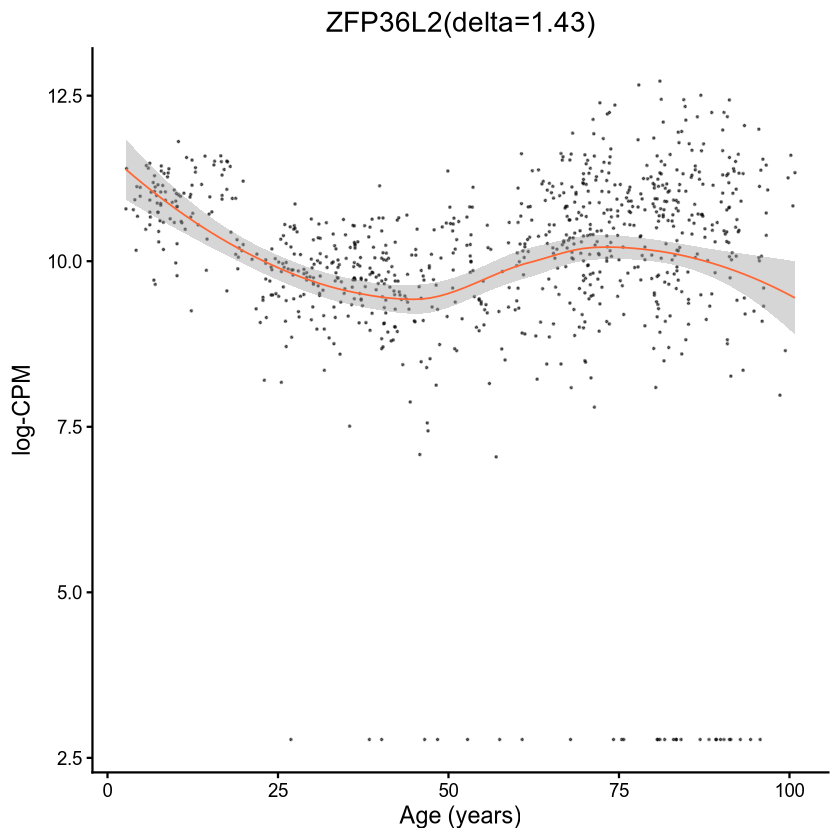

In [24]:
geneID = 'ZFP36L2'
logCPM.obs.i <- logCPM.obs[geneID,]
logCPM.fit.i <- logCPM.fit[geneID,]
df <- data.frame(
    Age = y$samples$Age_in_Years,
    logCPM_obs = logCPM.obs.i,
    logCPM_fit = logCPM.fit.i
)
sm <- smooth.spline(df$Age, df$logCPM_fit, df = 5)
sm_df <- data.frame(Age = sm$x, Fit = sm$y)
amp <- round(max(sm$y) - min(sm$y), 2)
p <- ggplot(df, aes(x = Age, y = logCPM_obs)) +
    geom_point(color = "black", size = 0.2, alpha = 0.5) +
    #geom_line(data = sm_df, aes(x = Age, y = Fit), color = "#1E3F66", size = 1.5) +
    geom_smooth(method = 'loess',col='#FF6633',size = 0.5)+
    theme_classic(base_size = 14) +
    labs(title = paste0(geneID, "(delta=", amp, ")"),
         x = "Age (years)", y = "log-CPM") +
    theme(plot.title = element_text(hjust = 0.5))
p
ggsave2(paste0('/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/',geneID,cell_type_name,'_loess.pdf'),p)

## Core NDNs

In [329]:
genelist = c('AREG','PDE4B','CXCL2','HIF1A','CDKN1A','SESN2','NLRP3','CXCL8')

#genelist = c()
p_list = list()
for(i in genelist) {
    geneID = i
    logCPM.obs.i <- logCPM.obs[geneID,]
    logCPM.fit.i <- logCPM.fit[geneID,]
    df <- data.frame(
        Age = y$samples$Age_in_Years,
        logCPM_obs = logCPM.obs.i,
        logCPM_fit = logCPM.fit.i
    )
    sm <- smooth.spline(df$Age, df$logCPM_fit, df = 5)
    sm_df <- data.frame(Age = sm$x, Fit = sm$y)
    amp <- round(max(sm$y) - min(sm$y), 2)
    p <- ggplot(df, aes(x = Age, y = logCPM_obs)) +
        geom_point(color = "black", size = 0.2, alpha = 0.5) +
        #geom_line(data = sm_df, aes(x = Age, y = Fit), color = "#1E3F66", size = 1.5) +
        geom_smooth(method = 'loess',col='#FF6633',size = 0.5)+
        theme_classic(base_size = 14) +
        labs(title = paste0(geneID, "(delta=", amp, ")"),
             x = "Age (years)", y = "log-CPM") +
        theme(plot.title = element_text(hjust = 0.5))
    p_list[[i]] = p
}

In [330]:
p = (p_list[[1]]+p_list[[2]]+p_list[[3]]+p_list[[4]]) | (p_list[[5]] + p_list[[6]]+p_list[[7]]+p_list[[8]])

In [331]:
ggsave2(paste0('/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/','8gene',cell_type_name,'_loess.pdf'),
        p,width=6,height=4)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


## CCR4+ CD8+ Tcm

In [444]:
genelist = c('TCF7','LEF1','CCR7','PECAM1','TNF','FAS','LGALS1','DDIT4','ZFP36L2','ZFP36')

#genelist = c()
p_list = list()
for(i in genelist) {
    geneID = i
    logCPM.obs.i <- logCPM.obs[geneID,]
    logCPM.fit.i <- logCPM.fit[geneID,]
    df <- data.frame(
        Age = y$samples$Age_in_Years,
        logCPM_obs = logCPM.obs.i,
        logCPM_fit = logCPM.fit.i
    )
    sm <- smooth.spline(df$Age, df$logCPM_fit, df = 5)
    sm_df <- data.frame(Age = sm$x, Fit = sm$y)
    amp <- round(max(sm$y) - min(sm$y), 2)
    p <- ggplot(df, aes(x = Age, y = logCPM_obs)) +
        geom_point(color = "black", size = 0.2, alpha = 0.5) +
        #geom_line(data = sm_df, aes(x = Age, y = Fit), color = "#1E3F66", size = 1.5) +
        geom_smooth(method = 'loess',col='#FF6633',size = 0.5)+
        theme_classic(base_size = 14) +
        labs(title = paste0(geneID, "(delta=", amp, ")"),
             x = "Age (years)", y = "log-CPM") +
        theme(plot.title = element_text(hjust = 0.5))
    p_list[[i]] = p
}

In [459]:
p = (p_list[[1]]+p_list[[2]]) /
     ( p_list[[3]]+p_list[[4]]) /
(p_list[[5]] + p_list[[6]]) /
 (p_list[[7]]+p_list[[8]]) /
(p_list[[9]]+p_list[[10]])

In [460]:
ggsave2(paste0('/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/','8gene_Tcm',cell_type_name,'_loess.pdf'),
        p,width=4,height=10)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


## CD27- Th1

In [468]:
genelist = c('CCR5','CX3CR1','GIMAP4','GIMAP7')

#genelist = c()
p_list = list()
for(i in genelist) {
    geneID = i
    logCPM.obs.i <- logCPM.obs[geneID,]
    logCPM.fit.i <- logCPM.fit[geneID,]
    df <- data.frame(
        Age = y$samples$Age_in_Years,
        logCPM_obs = logCPM.obs.i,
        logCPM_fit = logCPM.fit.i
    )
    sm <- smooth.spline(df$Age, df$logCPM_fit, df = 5)
    sm_df <- data.frame(Age = sm$x, Fit = sm$y)
    amp <- round(max(sm$y) - min(sm$y), 2)
    p <- ggplot(df, aes(x = Age, y = logCPM_obs)) +
        geom_point(color = "black", size = 0.2, alpha = 0.5) +
        #geom_line(data = sm_df, aes(x = Age, y = Fit), color = "#1E3F66", size = 1.5) +
        geom_smooth(method = 'loess',col='#FF6633',size = 0.5)+
        theme_classic(base_size = 14) +
        labs(title = paste0(geneID, "(delta=", amp, ")"),
             x = "Age (years)", y = "log-CPM") +
        theme(plot.title = element_text(hjust = 0.5))
    p_list[[i]] = p
}

In [469]:
p = (p_list[[1]]+p_list[[2]]) /
     ( p_list[[3]]+p_list[[4]])

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


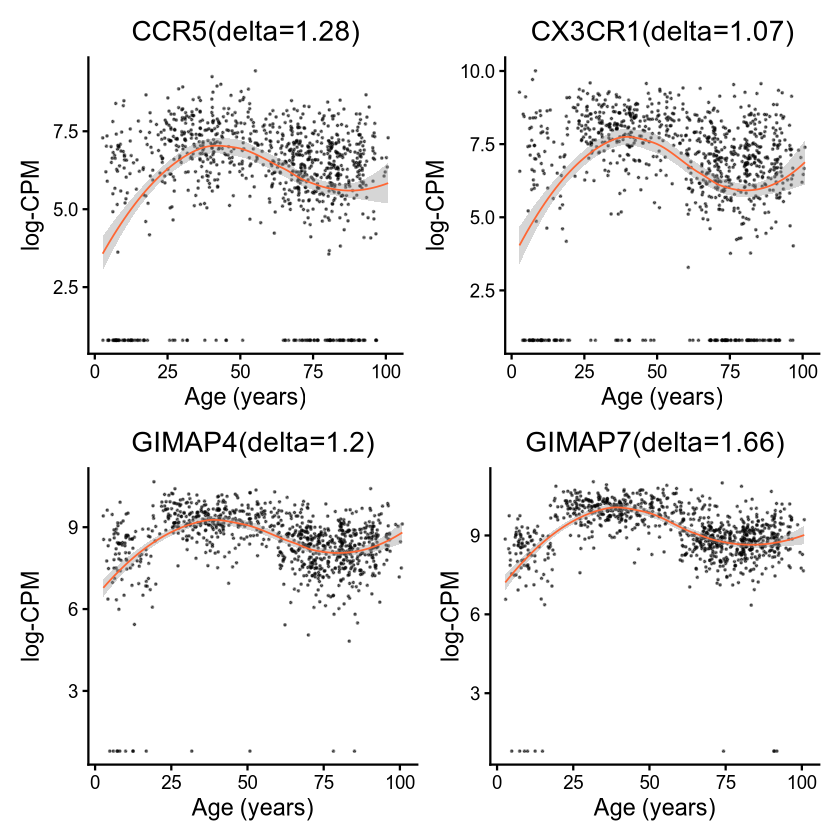

In [470]:
p

In [460]:
ggsave2(paste0('/home/liyanguo/MyImmuCell/08_supp_outputs/DEG_edgeR_Classification_L4/','8gene_CD27-Th1',cell_type_name,'_loess.pdf'),
        p,width=4,height=10)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


In [3]:
quiet_library <- function(...) {suppressPackageStartupMessages(library(...))}
quiet_library(edgeR)
quiet_library(dplyr)
quiet_library(purrr)
quiet_library(furrr)
quiet_library(future)
quiet_library(anndataR)
quiet_library(openxlsx)
quiet_library(BiocParallel)
quiet_library(ggplot2)
quiet_library(tidyverse)
quiet_library(pheatmap)
quiet_library(cowplot)
quiet_library(splines)
quiet_library(Seurat)
quiet_library(parallel)
quiet_library(cluster)
quiet_library(reshape2)
quiet_library(viridisLite)
quiet_library(ggplotify)
quiet_library(dtwclust)
quiet_library(ComplexHeatmap)
quiet_library(circlize)
plan(multisession, workers = 24)
options(future.globals.maxSize = 1024^5*10)
set.seed(0)